# Coldpress vs NERC+Coldfront (Traditional K8s)

Verifying namespaces and infrastructure...

[OK] researcher-a namespace exists
[OK] researcher-a-storage PVC exists
[OK] researcher-a-data-explorer pod exists
[OK] researcher-b namespace exists

[OK] Setup complete


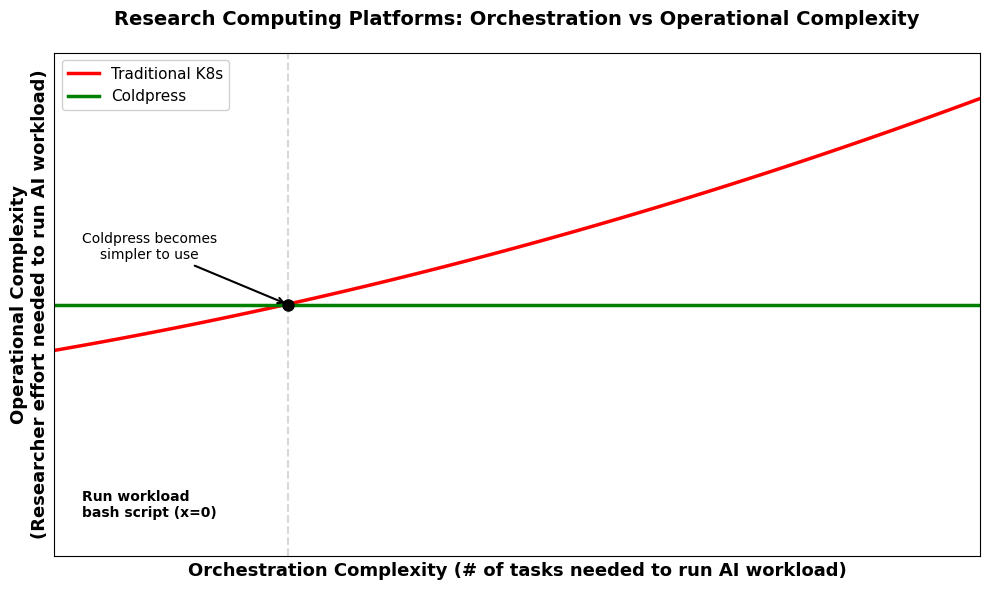

In [1]:
import subprocess
import time
import json
from demo_func import *
plot_complexity_comparison()

### Why use Coldpress?

Coldpress is an experiment orchestration platform that enables a relatively flat operational complexity despite increasing orchestration complexity i.e. you do more complex workflows with the same user effort. 

```bash 
 -------------------------
|        Coldpress        |
 -------------------------
|  Kueue+JobSet / Slinky  |

```


The multiplicative effect with Coldpress is that its value grows when repeatedly deploying an experiment, either unchanged or with changes typical of tuning and design space exploration. This is especially valuable for an evolving field like AI where every aspect of the workload (models, datasets, benchmarks, hardware) can frequently change, and minor perturbations can significantly impact results (typical of HPC-like workloads). 


### Value Proposition

We can divide the value proposition of Coldpress as an experiment orchestration platform into two high level buckets:


1) **Increased orchestrational complexity**
    - Features that enable complex multi-step workflows through automated system orchestration
    - The system does more, so the user doesn't have to


2) **Invariant operational complexity**
    - Features that leverage the above automation in order to prevent researcher operational burden from scaling with orchestration complexity
    - User interface stays simple even as the system orchestrates more complex tasks


### Features that Enable Greater Orchestration Complexity through Automation
**Kueue & JobSet Integration**
- Provides gang scheduling, resource management, and deadlock prevention
- Enables complex task chaining with dependencies
- User does not have to manually set up jobsets, queues, annotations etc.

**Automated Garbage Collection & Error Handling & Result Tagging**
- Reduces risk of dangling resources consuming GPU quota after tasks finish or fail
- Can queue up multiple experiments in one go since resources are freed after each experiment and results appropriately tagged

**System State Discovery**
- Captures comprehensive system state metrics (GPU topology, RDMA config, resource availability) that provide context to experiment results
- Enables explaining result variations and recreating experiment conditions

**Node Selection**
- Currently a basic GPU-availability scoring implementation
- Can be customized for AI workloads without affecting native K8s scheduler
- Extensible to factor in topology, SLA, workload characteristics
- Improve system utilization: Map requirements to leftover resources (e.g. need 120 GB of memory → use 3 A100s vs the 2 more high demand H100s)

**Learning**
- Learn from recorded workload provenance and system discovery
- Instead of evaluating on a per use-case basis, map future workloads to past ones to automatically determine how to best deploy them


### Features that Maintain Invariant Operational Complexity

**Coldpress Templates**
- Portability across Coldpress managed resources/clusters
- Better provenance: manifest tracks exactly which workload was run and remains retrievable from the cluster
- Simplifies user interface through validated, admin-constrained workloads
- Reduces attack surfaces by validating parameter inputs (e.g. validating model strings as HuggingFace identifiers)

**Limited User Permissions**
- Unlike traditional K8s edit permissions that allow arbitrary workloads, Coldpress users can only interact with approved CRs
- Restricts users to specific admin-validated workloads instead of unrestricted pod execution

**SBOM (Software Bill of Materials)**
- Automated dependency tracking keeps user interface simple regardless of image complexity
- Challenge with prebuilt images:
    - Reduce container startup time
    - Difficult to track dependencies without image recipe
    - Recipes may not be available, or too many images to maintain
- Challenge with base image + runtime installs:
    - Great for BOM tracking
    - High overhead (e.g. building/installing PyTorch)
- Coldpress solution:
    - Start with images of known BOM (e.g. pytorch-x.y)
    - Pick image with majority of requirements already met
    - Templates can specify additional dependencies
    - Provenance automatically captures complete build process


### NERC+Coldfront usage model
- Users are assigned to namespaces
- Users (and admins) have broad permissions within that namespace
  - Create, delete, monitor pods/pvcs etc

### Coldpress usage model
- Users are assigned templates as Custom Resources
- Users can launch jobs for those templates by specifying a set of parameters
- Admin decides the range of allowed parameters
  - Coldpress does not inherently limit workloads
  - Can deploy arbitrary bash scripts and interactive workloads if admin allows it

## Workload Script (Used by Both Approaches)

This Python script runs **identically** in both Traditional K8s and Coldpress:

```python
#!/usr/bin/env python3

import os
import subprocess
import torch

from transformers import modeling_utils
if not hasattr(modeling_utils, "ALL_PARALLEL_STYLES") or modeling_utils.ALL_PARALLEL_STYLES is None:
    modeling_utils.ALL_PARALLEL_STYLES = ["tp", "none", "colwise", "rowwise"]

import transformers.utils.import_utils

def _bypass_check():
    pass

transformers.utils.import_utils.check_torch_load_is_safe = _bypass_check

from qwen_omni_utils import process_mm_info
from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor

DUMMY_VIDEO = "test_video.mp4"

if not os.path.exists(DUMMY_VIDEO):
    print("[INFO] Creating dummy video with ffmpeg...")
    subprocess.run(
        ["ffmpeg", "-y", "-f", "lavfi", "-i", "testsrc=size=224x224:rate=5",
         "-t", "2", "-pix_fmt", "yuv420p", DUMMY_VIDEO],
        check=True,
    )

assert os.path.exists(DUMMY_VIDEO), "ffmpeg failed to create dummy video"
print("[OK] ffmpeg works")

MODEL_NAME = "Qwen/Qwen2.5-Omni-7B"

print("[INFO] Loading model...")
model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="flash_attention_2",
    trust_remote_code=True,
)
model.disable_talker()

processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_NAME)
print("[OK] Model + processor loaded")

conversation = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful multimodal assistant."}],
    },
    {
        "role": "user",
        "content": [
            {"type": "video", "video": DUMMY_VIDEO},
            {"type": "text", "text": "What do you see in this video?"},
        ],
    },
]

text = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
audios, images, videos = process_mm_info(conversation, use_audio_in_video=False)
inputs = processor(text=text, videos=videos, audio=audios, images=images, 
                   return_tensors="pt", padding=True, use_audio_in_video=False)
inputs = inputs.to(model.device).to(model.dtype)

print("[INFO] Running generation...")
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=128)

decoded = processor.batch_decode(output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
answer = decoded[0].split("\nassistant\n")[-1].strip()

print("\n=== MODEL OUTPUT ===")
print(answer)
print("====================")
print("[SUCCESS] Minimal Qwen2.5-Omni + ffmpeg + flash-attn test completed")

```

## User Requirements

In [5]:
# User requirements - what the researcher actually cares about
user_requirements = {
    "model": "Qwen/Qwen2.5-Omni-7B",
    "prompt": "What do you see in this video?",
    "max_tokens": 128,
    "gpus_needed": 1,
    
    # For traditional K8s workflow
    "script": "deepti.py",
    "image": "quay.io/jschless/ml-dev-env:pytorch-2.9-numpy2"
}

## Get Available GPUs

In [9]:
node_configs = discover_gpu_nodes()

DISCOVERED GPU NODES

wrk-4:
  GPU: NVIDIA-A100-SXM4-40GB (ampere)
  Count: 4 x 40960 MB

wrk-6:
  GPU: NVIDIA-H100-80GB-HBM3 (hopper)
  Count: 4 x 81559 MB



# Traditional K8s Workflow (researcher-b)

In [10]:
# Get GPU tolerations for pod configuration
tolerations = get_gpu_tolerations(node_configs)

# Create pod with GPU configuration
pod_created = create_pod(
    pod_name="ml-workload",
    image=user_requirements['image'],
    gpus=user_requirements['gpus_needed'],
    tolerations=tolerations
)

# Wait for pod to be ready
pod_ready = wait_for_pod_ready("ml-workload")

# Copy and run the workload script
if pod_ready:
    import os
    baseline_dir = f"{os.getcwd()}/baseline"
    script_path = f"{baseline_dir}/{user_requirements['script']}"
    output = run_script(script_path, "ml-workload")

[OK] Pod 'ml-workload' created
[WAIT] Waiting for pod 'ml-workload' to be ready...
[OK] Pod is ready
[INFO] Copying script to pod...
[RUN] Executing script...
[OK] Script completed successfully

MODEL OUTPUT
Loading checkpoint shards: 100%|██████████| 5/5 [00:06<00:00,  1.22s/it]
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
[OK] Model + processor loaded
qwen-vl-utils using decord to read video.
Unused or unrecognized kwargs: images, return_tensors.
[INFO] Running generation...
/usr/local/lib/python3.12/dist-packages/transformers/models/qwen2_5_omni/modeling_qwen2_5_omni.py:447: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is //.cache/torch/ke

In [11]:
# Manually collect provenance before cleanup
provenance = collect_provenance("ml-workload", user_requirements)

[INFO] Collecting provenance...

PROVENANCE SUMMARY

Saved to: /tmp/provenance_ml-workload_20260405_115859.json
[WARNING] /tmp is ephemeral - will be lost on reboot

--------------------------------------------------------------------------------
USER CONFIGURATION
--------------------------------------------------------------------------------
  model: Qwen/Qwen2.5-Omni-7B
  prompt: What do you see in this video?
  max_tokens: 128
  gpus_needed: 1

--------------------------------------------------------------------------------
EXECUTION TIMELINE
--------------------------------------------------------------------------------

  Event                          Timestamp                          
  -----------------------------------------------------------------
  Pod Created                    2026-04-05T18:58:01Z               
  Pod Started                    2026-04-05T18:58:01Z               
  Provenance Collected           2026-04-05T11:58:56.690780         
  Phase             

In [12]:
# Manually cleanup resources
cleanup_pod("ml-workload")

[OK] Pod 'ml-workload' deleted


True

# Coldpress Workflow (researcher-a)

## Admin: Create WorkloadTemplate

Template embeds the same workload script with parameterization:

In [7]:
# Create WorkloadTemplate that embeds the workload
template_yaml = r'''
apiVersion: coldpress.io/v1
kind: WorkloadTemplate
metadata:
  name: deepti-qwen-parser
  namespace: coldpress-admin
spec:
  requirements:
    num_nodes: "1"
    gpus_per_node: "{num_gpus}"
    roce_nics_per_node: "0"
  user_params:
    - model_name
    - prompt
    - max_new_tokens
  allocator_params:
    - num_gpus
  image: "quay.io/jschless/ml-dev-env:pytorch-2.9-numpy2"
  env:
    - name: "HOME"
      value: "/tmp"
    - name: "TRANSFORMERS_CACHE"
      value: "/tmp/.cache/transformers"
    - name: "HF_HOME"
      value: "/tmp/.cache/huggingface"
    - name: "TRITON_CACHE_DIR"
      value: "/tmp/.triton"
  command: ["bash", "-c"]
  args:
    - |
      set -e
      mkdir -p /tmp/result
      cd /tmp/result

      cat << 'EOF' > /tmp/result/workload.py
      import os
      import subprocess
      import torch
      from transformers import modeling_utils

      # Fix for transformers post_init bug
      if not hasattr(modeling_utils, "ALL_PARALLEL_STYLES") or modeling_utils.ALL_PARALLEL_STYLES is None:
          modeling_utils.ALL_PARALLEL_STYLES = ["tp", "none", "colwise", "rowwise"]

      import transformers.utils.import_utils
      def _bypass_check(): pass
      transformers.utils.import_utils.check_torch_load_is_safe = _bypass_check

      from qwen_omni_utils import process_mm_info
      from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor

      DUMMY_VIDEO = "test_video.mp4"

      if not os.path.exists(DUMMY_VIDEO):
          print("[INFO] Creating dummy video with ffmpeg...")
          subprocess.run([
              "ffmpeg", "-y", "-f", "lavfi", "-i", "testsrc=size=224x224:rate=5",
              "-t", "2", "-pix_fmt", "yuv420p", DUMMY_VIDEO,
          ], check=True)

      assert os.path.exists(DUMMY_VIDEO), "ffmpeg failed to create dummy video"
      print("[OK] ffmpeg works")

      MODEL_NAME = "{model_name}"
      print(f"[INFO] Loading model: {{MODEL_NAME}}...")

      model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
          MODEL_NAME,
          torch_dtype=torch.bfloat16,
          device_map="auto",
          attn_implementation="flash_attention_2",
          trust_remote_code=True,
      )
      model.disable_talker()
      processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_NAME)
      print("[OK] Model + processor loaded")

      # Double braces {{{{ }}}} escape literal dict declarations for Coldpress templating
      conversation = [
          {{
              "role": "system",
              "content": [{{"type": "text", "text": "You are a helpful multimodal assistant."}}],
          }},
          {{
              "role": "user",
              "content": [
                  {{"type": "video", "video": DUMMY_VIDEO}},
                  {{"type": "text", "text": "{prompt}"}},
              ],
          }},
      ]

      text = processor.apply_chat_template(
          conversation,
          add_generation_prompt=True,
          tokenize=False,
      )

      audios, images, videos = process_mm_info(
          conversation,
          use_audio_in_video=False,
      )

      inputs = processor(
          text=text,
          videos=videos,
          audio=audios,
          images=images,
          return_tensors="pt",
          padding=True,
          use_audio_in_video=False,
      )

      inputs = inputs.to(model.device).to(model.dtype)

      print("[INFO] Running generation...")
      with torch.no_grad():
          output_ids = model.generate(
              **inputs,
              max_new_tokens={max_new_tokens},
          )

      decoded = processor.batch_decode(
          output_ids,
          skip_special_tokens=True,
          clean_up_tokenization_spaces=False,
      )

      answer = decoded[0].split("\\nassistant\\n")[-1].strip()

      print("\\n=== MODEL OUTPUT ===")
      print(answer)
      print("====================")
      print("[SUCCESS] Multimodal inference test completed")

      with open("/tmp/result/output.txt", "w") as f:
          f.write(answer)
      EOF

      echo "Executing workload.py..."
      python3 /tmp/result/workload.py 2>&1 | tee /tmp/result/output.log
  blocking:
    type: "completion"
  resources:
    limits:
      nvidia.com/gpu: "{num_gpus}"
  tolerate_all: true
  ephemeral_mounts:
    - target: "/tmp/result"
      size: "2000Mi"
  sys_mounts: []
  files_to_copy:
    - "output.txt"
    - "output.log"
    - "workload.py"

'''

with open('/tmp/deepti-qwen-template.yaml', 'w') as f:
    f.write(template_yaml)

result = subprocess.run(
    ["oc", "apply", "-f", "/tmp/deepti-qwen-template.yaml", "--as", "system:admin"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("[OK] WorkloadTemplate 'deepti-qwen-parser' created")
    print("\n  Template parameters:")
    print("    - user_params: model_name, prompt, max_new_tokens")
    print("    - allocator_params: num_gpus")
    print("\n  Note: Template embeds the same Python workload shown above")
else:
    print(f"[ERROR] Failed to create template: {result.stderr}")

[OK] WorkloadTemplate 'deepti-qwen-parser' created

  Template parameters:
    - user_params: model_name, prompt, max_new_tokens
    - allocator_params: num_gpus

  Note: Template embeds the same Python workload shown above


## User: Run Experiment

In [13]:
# Prepare experiment parameters (simplified - only what template needs)
experiment_params = {
    "model_name": user_requirements['model'],
    "prompt": user_requirements['prompt'],
    "max_new_tokens": str(user_requirements['max_tokens']),
    "num_gpus": str(user_requirements['gpus_needed'])
}

# Step 1: Submit job with system discovery
job_submitted = submit_job(
    job_name="qwen-demo", 
    template="deepti-qwen-parser", 
    params=experiment_params,
    discovery_templates=["user-system-snapshot"]
)

# Step 2: Wait for completion (CR auto-deleted when done)
job_completed = wait_for_completion("qwen-demo")

# Step 3: View provenance (automatically captured)
provenance_dir = get_provenance("qwen-demo")

# Step 4: View results (persisted in PVC)
results_dir = get_results("qwen-demo")

[OK] Job 'qwen-demo' submitted
     Discovery templates: user-system-snapshot
[WAIT] Waiting for job 'qwen-demo' to complete...
[OK] Job completed in 76 seconds (CR auto-deleted)
PROVENANCE SUMMARY

Results: /data/researcher-a/coldpress_results/qwen-demo-allocated-6fff5ad9-20260405_190348
[OK] Persisted in PVC forever

--------------------------------------------------------------------------------
USER CONFIGURATION
--------------------------------------------------------------------------------
  max_new_tokens: 128
  model_name: Qwen/Qwen2.5-Omni-7B
  num_gpus: 1
  prompt: What do you see in this video?

--------------------------------------------------------------------------------
EXECUTED SCRIPT (first 20 lines)
--------------------------------------------------------------------------------
  set -e
  mkdir -p /tmp/result
  cd /tmp/result
  
  cat << 'EOF' > /tmp/result/workload.py
  import os
  import subprocess
  import torch
  from transformers import modeling_utils
  
  # F